<a href="https://colab.research.google.com/github/vcsgmr/medvis/blob/main/medvis_%C3%9C2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MedVis 23 - Exercise Sheet 2 - Additional Material


---



# Preparation

Here the necessary libraries are included.

In [ ]:
!git clone https://github.com/vcsgmr/medvis.git
%cd medvis
%ls

Cloning into 'medvis'...
remote: Enumerating objects: 37, done.
remote: Counting objects: 100% (37/37), done.
remote: Compressing objects: 100% (33/33), done.
remote: Total 37 (delta 1), reused 33 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (37/37), 1.91 MiB | 7.42 MiB/s, done.
Resolving deltas: 100% (1/1), done.
/content/medvis/medvis/medvis/medvis/medvis/medvis/medvis
dataset1/  dataset2/  README.md  series-00000/  Untitled2.ipynb


In [ ]:
!pip install scipy
!pip install pydicom

import os # for file-handling
import numpy as np # maths
import matplotlib.pyplot as plt # plotting
from scipy import ndimage # image processing
from pydicom import dcmread # reading DICOM files
from skimage.measure import label, regionprops, regionprops_table
import cv2 as cv
import math



# Adding some noise for Task 3

In [ ]:
# this function adds the salt and pepper noise, you should not modify this

def add_salt_pepper_noise(img):
    # Need to produce a copy as to not modify the original image
    img_copy = img.copy()
    row, col = img_copy.shape
    salt_vs_pepper = 0.5
    amount = 0.04
    num_salt = np.ceil(amount * img_copy.size * salt_vs_pepper)
    num_pepper = np.ceil(amount * img_copy.size * (1.0 - salt_vs_pepper))

    # Add Salt noise
    coords = [np.random.randint(0, i - 1, int(num_salt)) for i in img_copy.shape]
    img_copy[tuple(coords)] = 900  # Set salt to 255 (white)
    # Add Pepper noise
    coords = [np.random.randint(0, i - 1, int(num_pepper)) for i in img_copy.shape]
    img_copy[tuple(coords)] = 0     # Set pepper to 0 (black)

    return img_copy

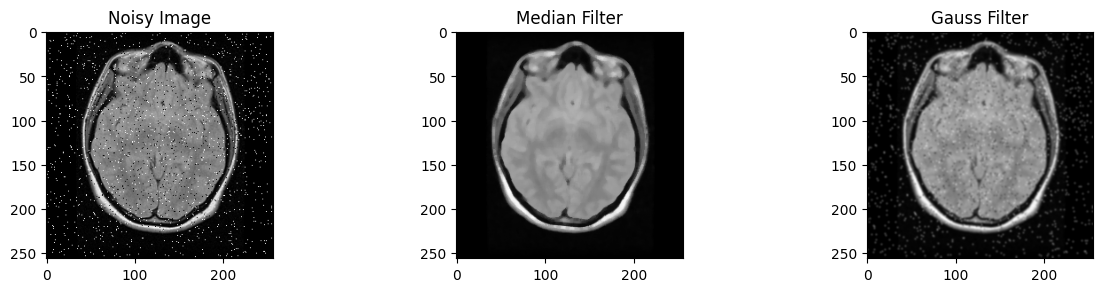

In [ ]:
# read one image and apply the noise
dcm_slice = dcmread("dataset1/brain_011.dcm")
noisy_img = add_salt_pepper_noise(np.array(dcm_slice.pixel_array))


#################################################
# this might be a good place to add the filters #
#################################################


import cv2
import numpy as np
median = cv2.medianBlur(noisy_img, ksize=5)
gauss = cv2.GaussianBlur(noisy_img, ksize=(5, 5), sigmaX=1.0)

# Create a figure (window)
fig = plt.figure(figsize=(15,10))

# display using gray levels
ax1 = fig.add_subplot(3, 3, 1)
ax1.set_title('Noisy Image')
ax1.imshow(noisy_img, cmap='gray')

ax2 = fig.add_subplot(3, 3, 2)
ax2.set_title('Median Filter')
ax2.imshow(median, cmap='gray')

ax3 = fig.add_subplot(3, 3, 3)
ax3.set_title('Gauss Filter')
ax3.imshow(gauss, cmap='gray')


# utils

In [ ]:


from typing import Tuple, Optional, Union


COLOR_MAP = {
    "red": (1, 0, 0),
    "green": (0, 1, 0),
    "blue": (0.35, 0.35, 1),
    "yellow": (1, 1, 0),
    "orange": (1, 0.65, 0),
    "black": (0, 0, 0),
    "white": (1, 1, 1)
}

def plot_images(images, titles=None, cmap="gray", cols=3, figsize=(15, 10)):
    n = len(images)

    if titles is None:
        titles = [""] * n

    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=figsize)

    if n == 1:
        axes = [axes]
    else:
        axes = axes.ravel()

    for ax, img, title in zip(axes, images, titles):
        ax.imshow(img, cmap=cmap)
        ax.set_title(title)
        ax.axis("off")

    for ax in axes[n:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

def create_border_mask(mask: np.ndarray, kernel_radius: int) -> np.ndarray:
    """Return a border mask (1 for border pixels) using morphology.

    Uses erosion with a square kernel of radius `kernel_radius` and
    subtracts the eroded mask from the original to get the border.
    This is vectorized and much faster than Python loops.
    """
    if not isinstance(mask, np.ndarray):
        raise TypeError("create_border_mask: expected numpy.ndarray")
    if mask.ndim != 2:
        raise ValueError(f"create_border_mask: expected 2D mask, got ndim={mask.ndim}")

    # ensure binary uint8 mask (0/1)
    bin_mask = (mask == 1).astype(np.uint8)

    k = kernel_radius * 2 + 1
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (k, k))
    eroded = cv2.erode(bin_mask, kernel)
    border = bin_mask - eroded
    return border.astype(np.uint8)

def gray2rgb(img):
    # bereits RGB
    if img.ndim == 3 and img.shape[2] == 3:
        return img

    # Graubild → RGB
    if img.ndim == 2:
        return np.stack((img, img, img), axis=2)

    raise ValueError("Unsupported image shape")


def ensure_gray_2d(img: np.ndarray) -> np.ndarray:
    """Ensure the image is a 2D grayscale numpy array.

    - If RGB (H,W,3) -> returns mean across channels as float64.
    - If already 2D -> returned unchanged.
    - Raises TypeError/ValueError on invalid input.
    """
    if not isinstance(img, np.ndarray):
        raise TypeError(f"ensure_gray_2d: expected numpy.ndarray, got {type(img)}")
    if img.ndim == 3:
        if img.shape[2] == 3:
            return np.mean(img, axis=2)
        else:
            return img[...,0]
    if img.ndim == 2:
        return img
    if img.ndim == 4:
        return img[...,0]
    raise ValueError(f"ensure_gray_2d: unsupported image ndim {img.ndim}")

def ensure_rgb(img: np.ndarray) -> np.ndarray:
    """Ensure the image is a 3D RGB numpy array.

    - If 2D grayscale (H,W) -> returns (H,W,3) by stacking the channel.
    - If already 3D -> returned unchanged.
    - Raises TypeError/ValueError on invalid input.
    """
    if not isinstance(img, np.ndarray):
        raise TypeError(f"ensure_rgb: expected numpy.ndarray, got {type(img)}")
    if img.ndim == 2:
        return np.dstack([img, img, img])
    if img.ndim == 3:
        return img.copy()
    raise ValueError(f"ensure_rgb: unsupported image ndim {img.ndim}")

def ensure_dtype(img: np.ndarray, dtype=np.float32) -> np.ndarray:
    """
    Convert image to target dtype with consistent scaling.

    Conventions:
    - float32: normalized to [0, 1]
    - uint8:   [0, 255]
    - uint16:  [0, 65535]
    """

    if not isinstance(img, np.ndarray):
        raise TypeError("ensure_dtype: expected numpy array")

    src = img.dtype
    dst = np.dtype(dtype)

    # already correct dtype
    if src == dst:
        return img

    # ---------- TO FLOAT ----------
    if dst == np.float32:
        if src == np.uint8:
            return img.astype(np.float32) / 255.0
        elif src == np.uint16:
            return img.astype(np.float32) / 65535.0
        elif np.issubdtype(src, np.floating):
            return img.astype(np.float32)
        elif src == np.int16:
            img_float = img.astype(np.float32)
            img_min = img_float.min()
            img_max = img_float.max()

            if img_max == img_min:
                return np.zeros_like(img_float, dtype=np.float32)

            return (img_float - img_min) / (img_max - img_min)

        else:
            raise TypeError(f"Unsupported conversion: {src} → float32")

    # ---------- FROM FLOAT ----------
    if np.issubdtype(src, np.floating):
        img_clipped = np.clip(img, 0.0, 1.0)

        if dst == np.uint8:
            return (img_clipped * 255.0).round().astype(np.uint8)
        elif dst == np.uint16:
            return (img_clipped * 65535.0).round().astype(np.uint16)
        else:
            return img_clipped.astype(dst)

    # ---------- UINT ↔ UINT ----------
    if src == np.uint8 and dst == np.uint16:
        return (img.astype(np.uint16) * 257)  # 255 → 65535 Mapping

    if src == np.uint16 and dst == np.uint8:
        return (img / 257).round().astype(np.uint8)

    # ---------- fallback ----------
    return img.astype(dst)

def plot(img: Union[np.ndarray, list], name: str="simple plot", gray: bool=False, enable_stop: bool=False, fullscreen: bool=False) -> None:
    # input validation
    if not isinstance(img, (np.ndarray, list)):
        raise TypeError(f"plot: 'img' must be numpy array or list-like, got {type(img)}")
    if img.ndim not in (2, 3):
        raise ValueError(f"plot: expected 2D or 3D image, got shape {img.shape}")

    fig, ax = plt.subplots()
    fig.canvas.manager.set_window_title(name)
    if img.ndim == 2:
        ax.imshow(img, cmap='gray')
    else:
        ax.imshow(img)
    ax.axis('off')

    if fullscreen:
        manager = fig.canvas.manager
        try:
            # Qt5Agg, Qt4Agg
            manager.window.showMaximized()
        except AttributeError:
            try:
                # TkAgg (Windows)
                manager.window.state('zoomed')
            except AttributeError:
                try:
                    # WXAgg
                    manager.frame.Maximize(True)
                except AttributeError:
                    pass

    plt.show(block=enable_stop)

def plot_interactive(img: np.ndarray, name: str, max_clicks: int=5) -> Union[Tuple[int, int], list]:
    """
    Zeigt das Bild an und sammelt `max_clicks` Klicks vom Benutzer.

    Returns:
        - Wenn max_clicks=1: einen einzelnen Seed (tuple)
        - Sonst: Liste von Seeds
    """
    seeds_local = []

    fig, ax = plt.subplots(figsize=(13, 9))
    ax.imshow(img, cmap='gray')
    ax.set_title(name)

    def onclick_local(event):
        nonlocal seeds_local
        if event.ydata is None or event.xdata is None:
            return
        new_seed = (int(event.ydata), int(event.xdata))
        seeds_local.append(new_seed)
        # print(f"Seed {len(seeds_local)}/{max_clicks} gewählt: {new_seed}")
        if len(seeds_local) >= max_clicks:
            print(f"Maximale Anzahl von {max_clicks} Seeds erreicht. Fenster wird geschlossen.")
            plt.close()

    cid = fig.canvas.mpl_connect('button_press_event', onclick_local)
    plt.show()

    # Wenn nur 1 Seed gesammelt wurde, gib ihn einzeln zurück
    if max_clicks == 1 and seeds_local:
        return seeds_local[0]
    return seeds_local

def apply_adaptive_overlay(img: np.ndarray, mask: np.ndarray, color_channel: int=0, dimm:bool=True, factor:float=0.15) -> np.ndarray:
    if len(img.shape) == 2:
        img = gray2rgb(img)
    mask = (mask == 1)

    img[..., color_channel] = img[..., color_channel] + factor * mask

    if dimm:
        channels = {0, 1, 2}
        channels_dimm = channels - {color_channel}
        channels_dimm = list(channels_dimm) # umwandlung set -> list , damit referenzierbar
        img[..., channels_dimm[0]] = img[..., channels_dimm[0]] - factor * mask
        img[..., channels_dimm[1]] = img[..., channels_dimm[1]] - factor * mask

    # Clip auf gültigen Bereich [0, 1]
    img = np.clip(img, 0, 1)
    return img

def apply_overlay(img: np.ndarray, mask: np.ndarray, color: str="red") -> np.ndarray:
    img_overlay = img.copy()
    img_overlay = gray2rgb(img_overlay) if len(img_overlay.shape) == 2 else img_overlay

    # Check if shapes match
    if mask.shape != img_overlay.shape[:2]:
        print(f"Warning: mask shape {mask.shape} does not match image shape {img_overlay.shape[:2]}")
        return img_overlay

    mask = (mask == 1)
    if len(img_overlay.shape) == 3:
        color_val = color_str_to_val(color)
        img_overlay[mask] = color_val
    elif len(img_overlay.shape) == 2:
        color_val = color_str_to_val(color)
        img_overlay[mask] = color_val[0]
    else:
        print("wrong input img")
    return img_overlay

def color_str_to_val(color: str) -> Tuple[float, float, float]:
    if color in COLOR_MAP:
        return COLOR_MAP[color]
    else:
        print("wrong color")
        return COLOR_MAP["red"]

def mask_diff(img, mask1, mask2):
    # Bild nach RGB und float [0, 1]
    img = ensure_rgb(img)
    img = ensure_dtype(img, np.float32)

    # Masken sinnvoll binarisieren
    mask1 = mask1 > 0
    mask2 = mask2 > 0

    # robust, kein uint8-subtraction Problem
    added = mask2 & ~mask1        # neu dazugekommen
    subtracted = mask1 & ~mask2   # verloren gegangen

    imgdiff = apply_overlay(img, subtracted.astype(np.uint8), "red")
    imgdiff = apply_overlay(imgdiff, added.astype(np.uint8), "green")

    return imgdiff

def mask_diff_eval(img, mask1, mask2):
    img = ensure_rgb(img)
    mask1 = (mask1 == 1).astype(np.uint8)
    mask2 = (mask2 == 1).astype(np.uint8)
    diff = mask2 - mask1 + 1
    added = (diff == 2).astype(np.uint8)
    subtracted = (diff == 0).astype(np.uint8)

    imgdiff = apply_overlay(img, subtracted, "blue")
    imgdiff = apply_overlay(imgdiff, added, "red")

    return imgdiff

def mask_overlay(img: np.ndarray, adaptive_masks: Optional[Union[np.ndarray, list]]=None, masks: Optional[Union[np.ndarray, list]]=None, color_adaptive: str="red", color: str="yellow", border: bool=True, dimm: bool=True) -> None:
    img_seg_raw = img.copy()
    img_seg_raw = gray2rgb(img_seg_raw) if len(img_seg_raw.shape) == 2 else img_seg_raw
    if adaptive_masks is not None:
        if isinstance(adaptive_masks, np.ndarray):
            adaptive_masks = [adaptive_masks]
        for adaptive_mask in adaptive_masks:
            img_seg_raw = apply_adaptive_overlay(img_seg_raw, adaptive_mask, 2, dimm=dimm)
            if border:
                mask_border = create_border_mask(adaptive_mask, kernel_radius=2)
                img_seg_raw = apply_overlay(img_seg_raw, mask_border, color_adaptive)

    if masks is not None:
        if isinstance(masks, np.ndarray):
            masks = [masks]
        for mask in masks:
            img_seg_raw = apply_overlay(img_seg_raw, mask, color)

    return img_seg_raw

def plot_mask_diff(img_rgb: np.ndarray, mask1: np.ndarray, mask2: np.ndarray, name: str = "mask diff", enable_stop: bool=False) -> None:

    imgdiff = mask_diff(img_rgb, mask1, mask2)

    # plot
    fig, ax = plt.subplots()
    fig.canvas.manager.set_window_title(name)
    ax.set_title("imgdiff (added green, removed red)")
    ax.imshow(imgdiff)
    ax.axis('off')
    plt.show(block=enable_stop)

def plot_mask_overlay(img: np.ndarray, adaptive_masks: Optional[Union[np.ndarray, list]]=None, masks: Optional[Union[np.ndarray, list]]=None, border: bool=True, color_adaptive: str="red", color: str="yellow", name: str="segmented image", dimm: bool=True, enable_stop: bool=False) -> None:
    img_seg_raw = mask_overlay(img, adaptive_masks, masks, color_adaptive, color, border, dimm)
    plot(img_seg_raw, name, enable_stop=enable_stop)


# 4 Image Segmentation


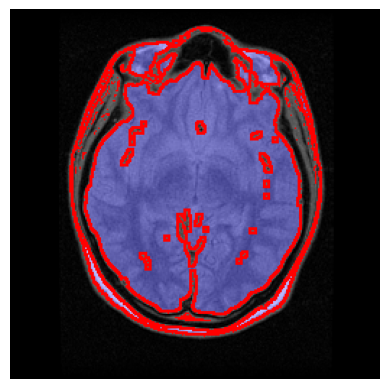

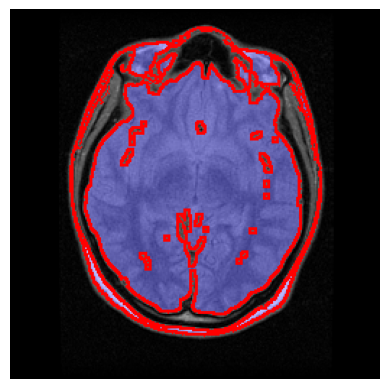

In [ ]:
dcm_slice_18 = dcmread("dataset1/brain_018.dcm")
dcm_slice_18 = ensure_dtype(np.array(dcm_slice.pixel_array), np.float32)

threshold = 0.4
segmentation = dcm_slice_18>threshold

plot(mask_overlay(dcm_slice_18, adaptive_masks=segmentation, color="red"))

# label connected components
label_im = label(segmentation)
label_im # <- matrix in which each pixel gets a label
# calculates statistics over all regeions
regions = regionprops(label_im)
# sort the regions in ascending order of size
lst_sorted = sorted(regions, key=lambda x: x.area)
# take the data from the last index from the list
graymatter = label_im == lst_sorted[-1].label

plot(mask_overlay(dcm_slice_18, adaptive_masks=graymatter, color="red"))


# plt.imshow(dcm_slice_18, cmap='gray')

# 5 Morphological Operations

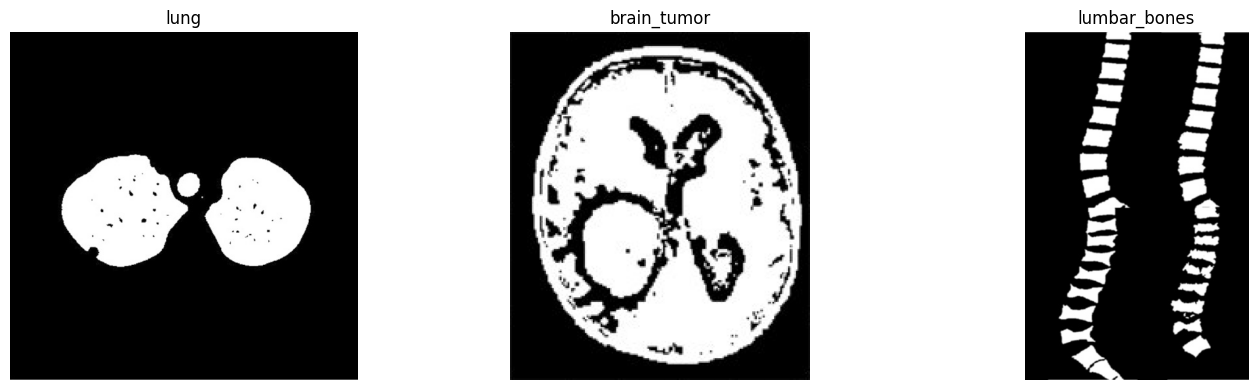

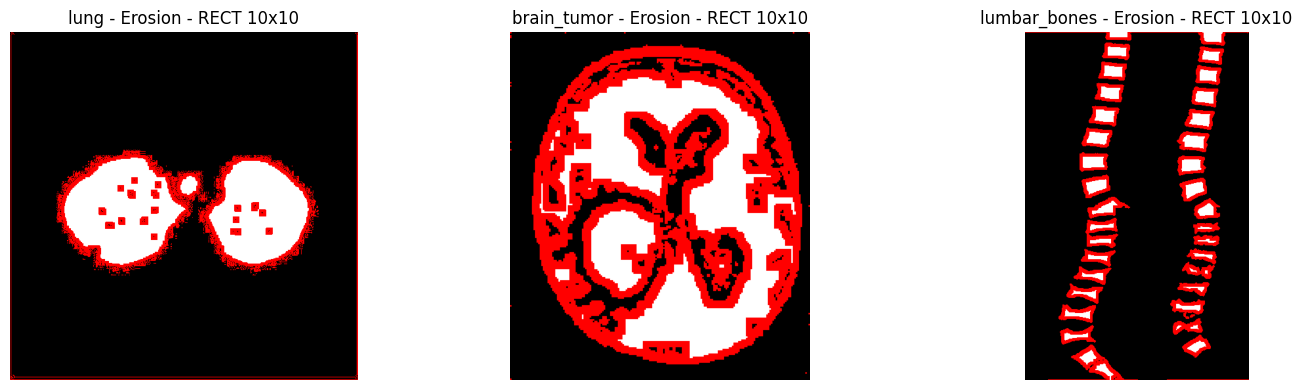

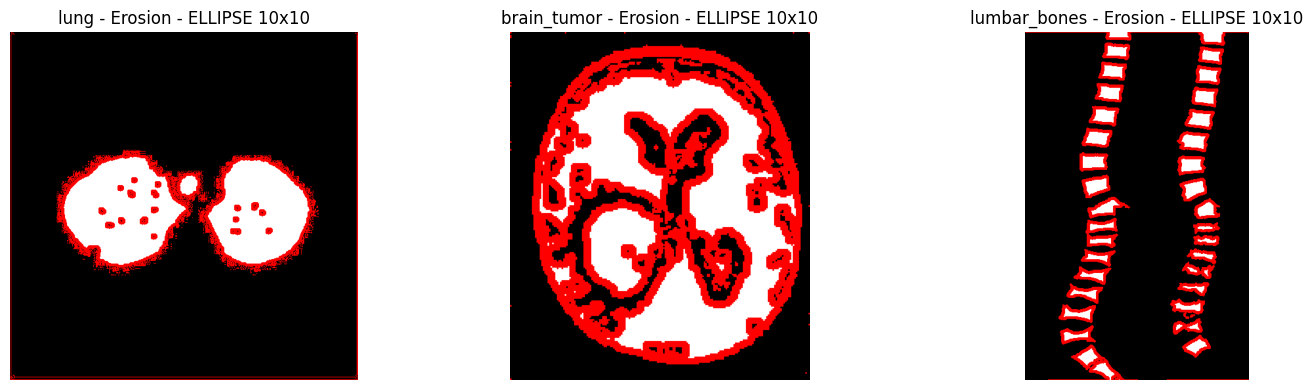

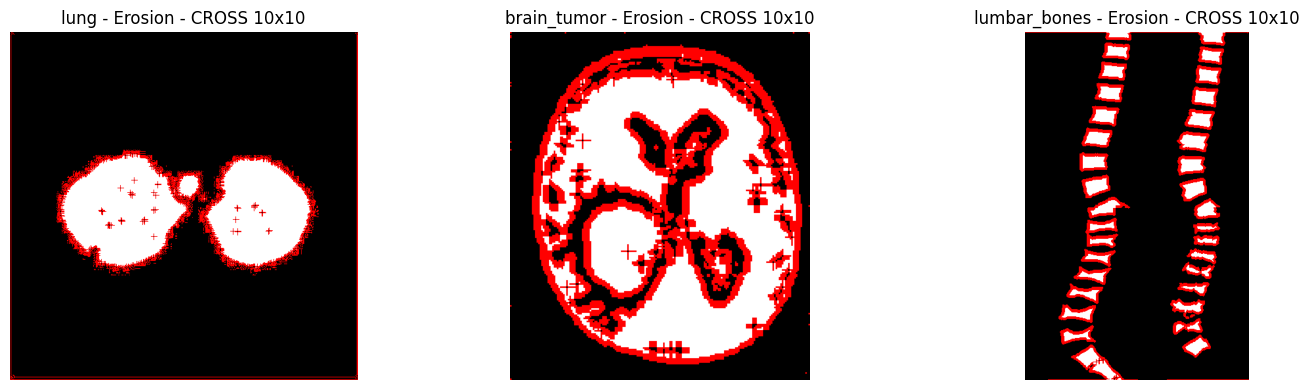

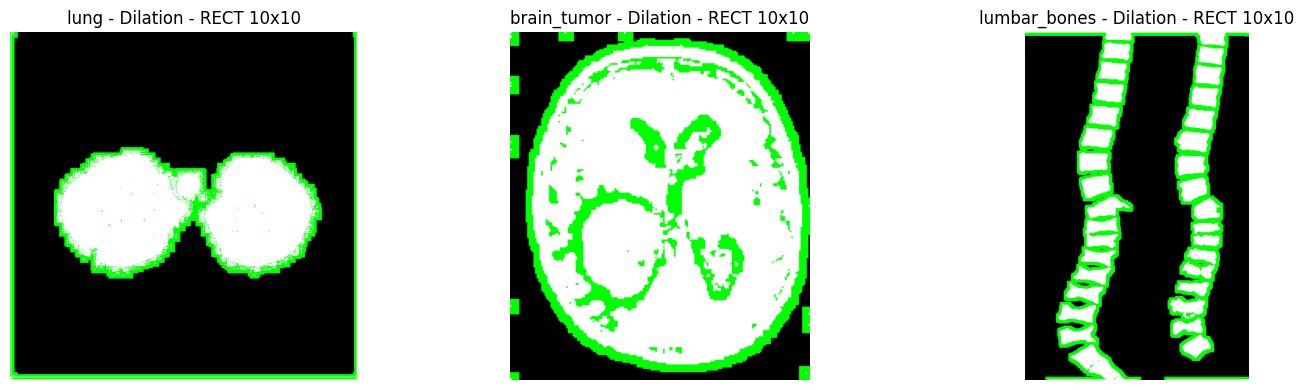

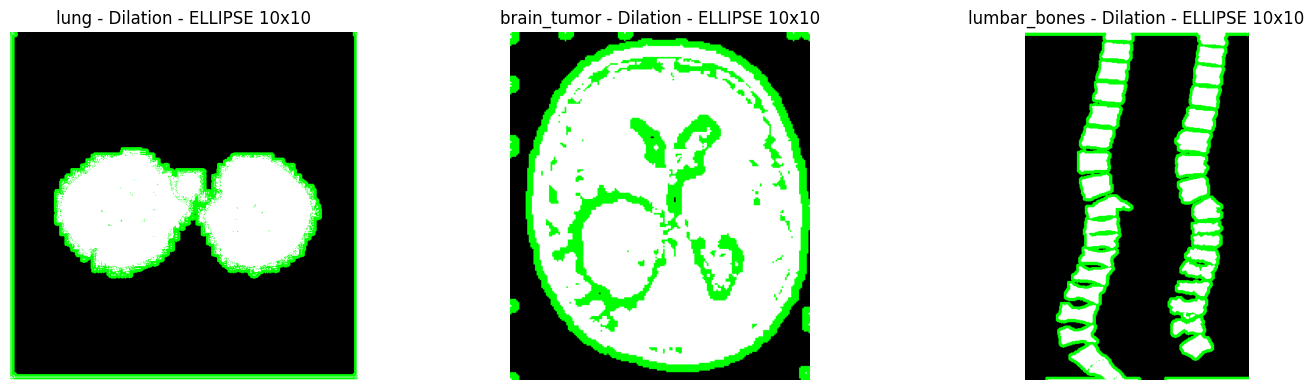

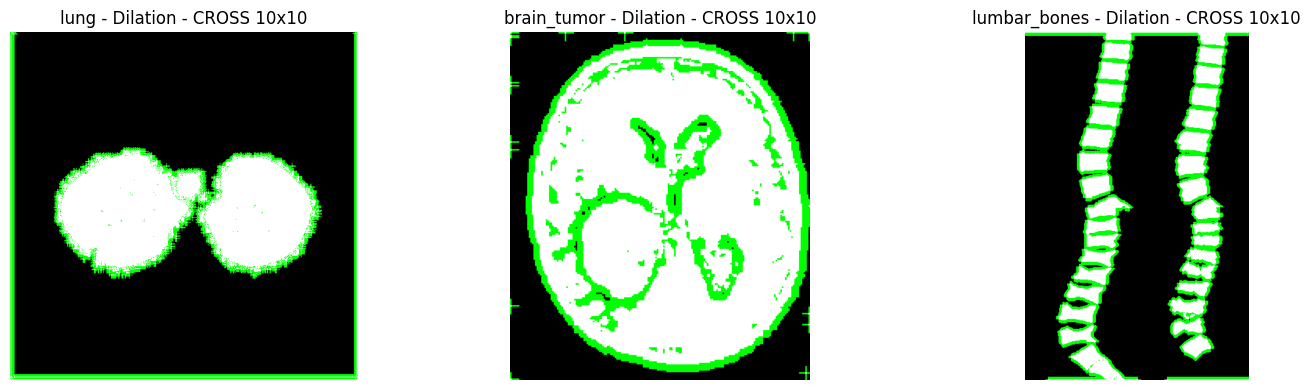

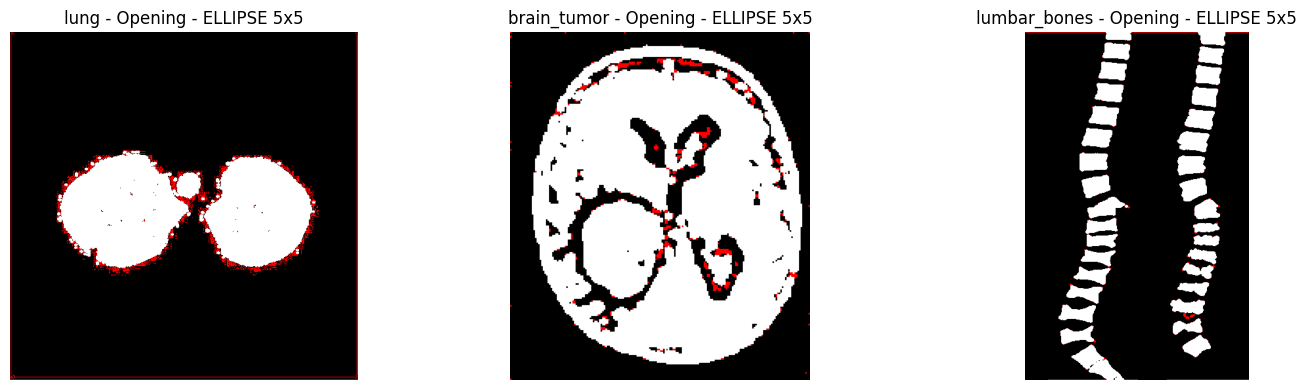

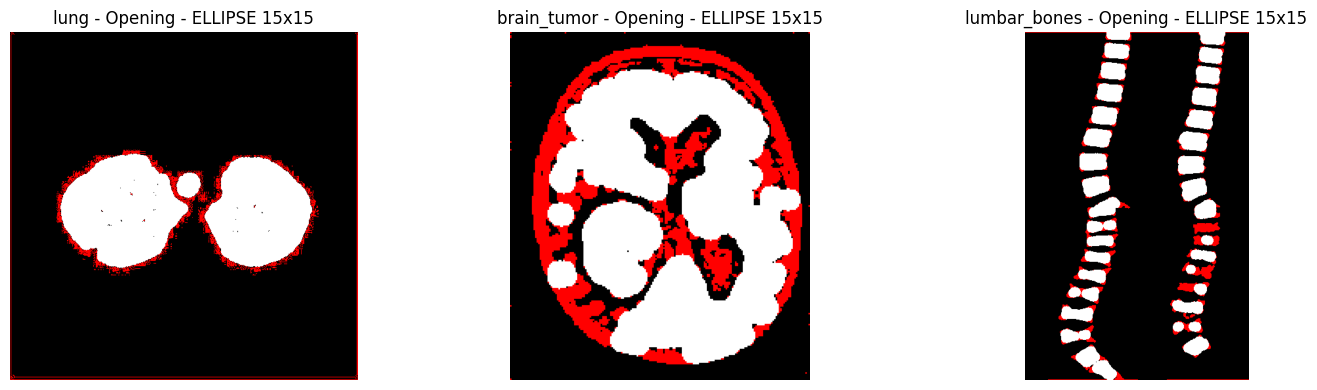

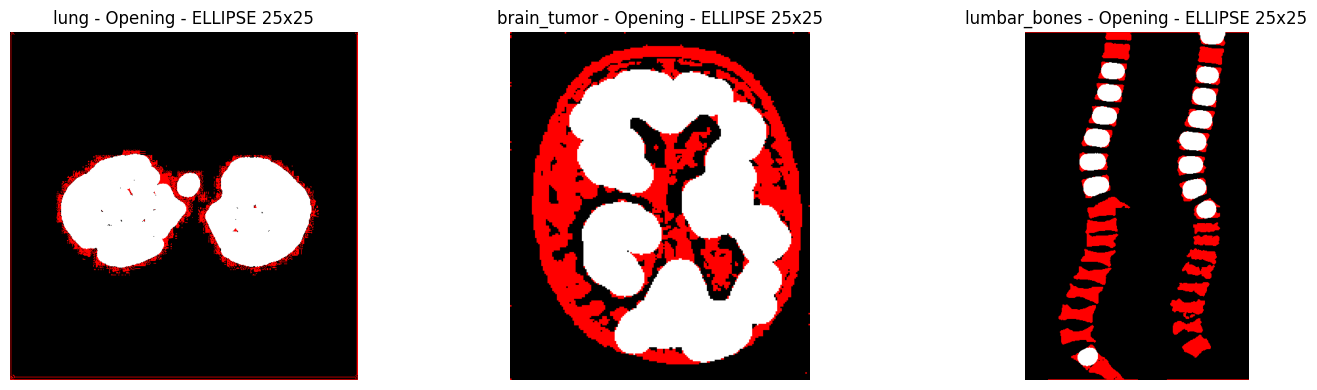

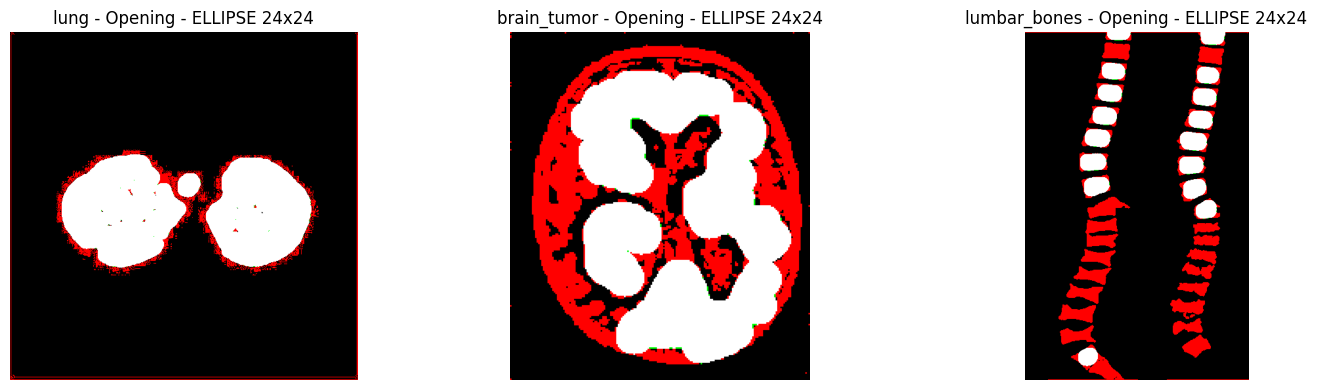

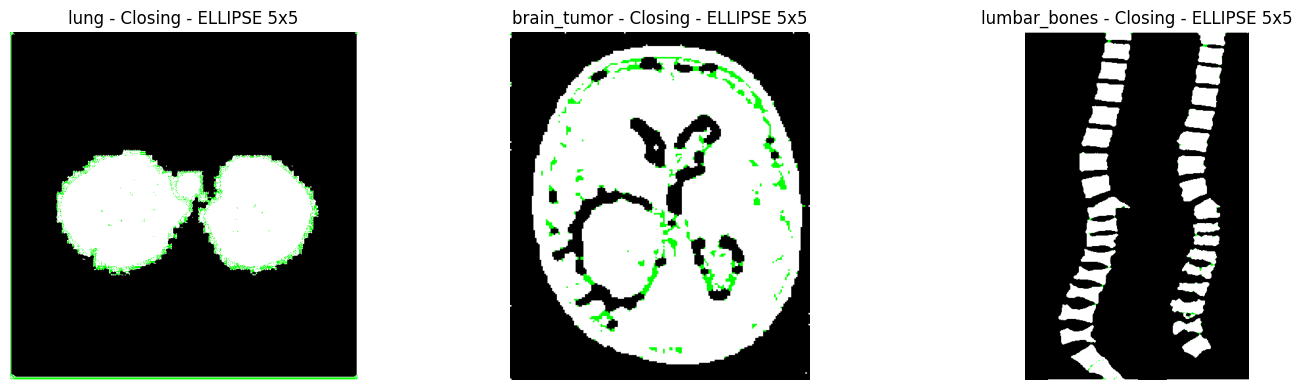

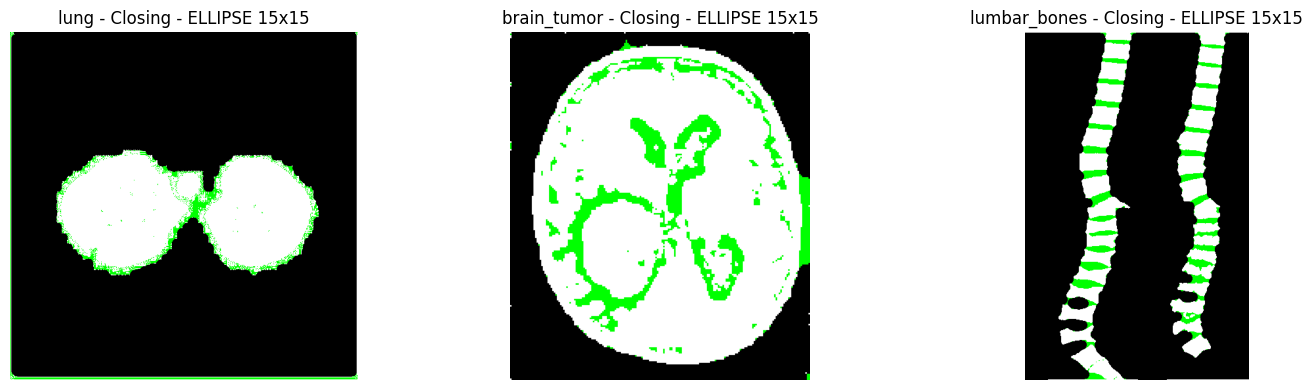

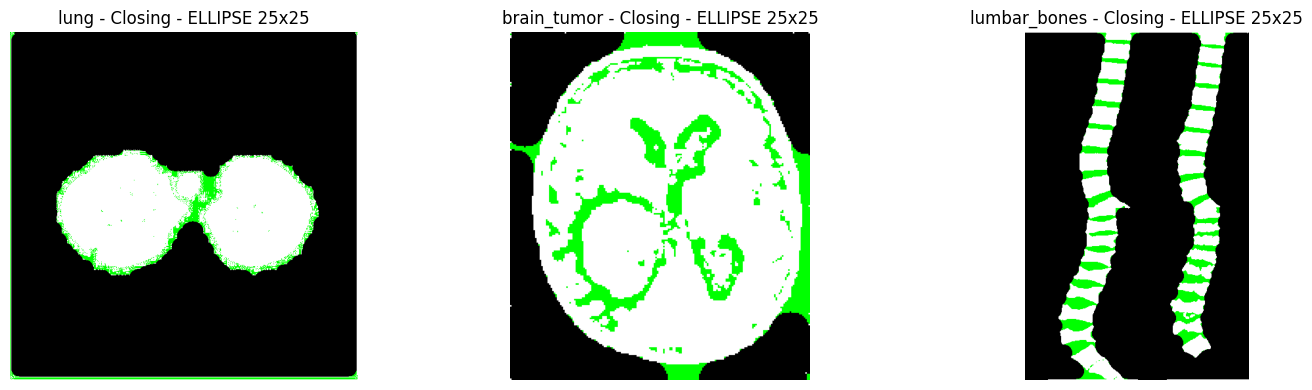

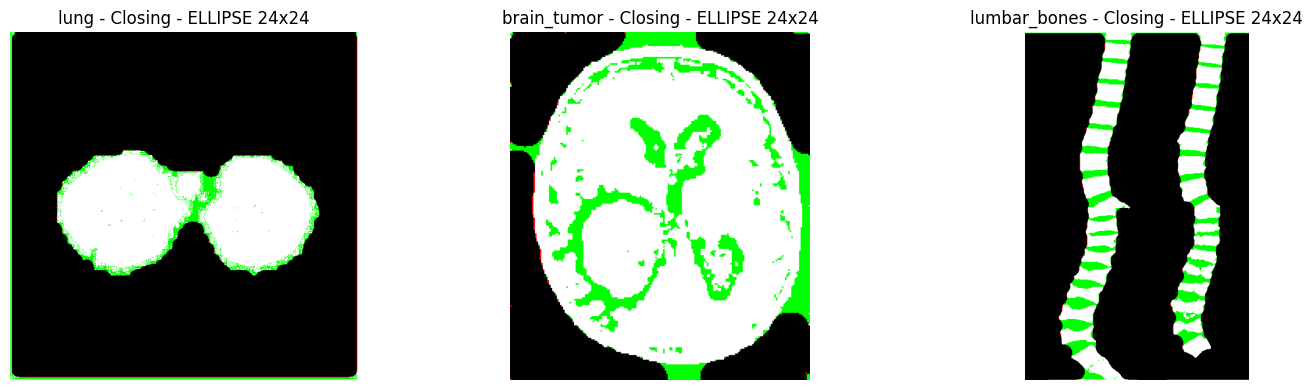

In [ ]:
brain_blood_vessels = cv.imread('./dataset2/brain_blood_vessels.png', cv.IMREAD_GRAYSCALE)
lung = cv.imread('./dataset2/lung.png', cv.IMREAD_GRAYSCALE)
brain_tumor = cv.imread('./dataset2/brain_tumor.png', cv.IMREAD_GRAYSCALE)
lumbar_bones = cv.imread('./dataset2/4_lumbar_bones.png', cv.IMREAD_GRAYSCALE)

kernel_list = [
    ("RECT 10x10", cv.getStructuringElement(cv.MORPH_RECT, (10, 10))),
    ("ELLIPSE 10x10", cv.getStructuringElement(cv.MORPH_ELLIPSE, (10, 10))),
    ("CROSS 10x10", cv.getStructuringElement(cv.MORPH_CROSS, (10, 10)))
]

ellipse_kernel_list = [
    ("ELLIPSE 5x5", cv.getStructuringElement(cv.MORPH_ELLIPSE, (5, 5))),
    ("ELLIPSE 15x15", cv.getStructuringElement(cv.MORPH_ELLIPSE, (15, 15))),
    ("ELLIPSE 25x25", cv.getStructuringElement(cv.MORPH_ELLIPSE, (25, 25))),
    ("ELLIPSE 24x24", cv.getStructuringElement(cv.MORPH_ELLIPSE, (24, 24)))
]

lung_mask = (lung > 0).astype(np.float32)
brain_tumor_mask = (brain_tumor > 20).astype(np.float32)
lumbar_bones_mask = (lumbar_bones > 30).astype(np.float32)

plot_images(
    [lung, brain_tumor, lumbar_bones],
    ["lung", "brain_tumor", "lumbar_bones"],
    cols=3,
    figsize=(15, 4)
)

operations = [
    (
        "Erosion",
        lambda mask, kernel: cv.erode(mask, kernel, iterations=1),
        kernel_list
    ),
    (
        "Dilation",
        lambda mask, kernel: cv.dilate(mask, kernel, iterations=1),
        kernel_list
    ),
    (
        "Opening",
        lambda mask, kernel: cv.morphologyEx(mask, cv.MORPH_OPEN, kernel, iterations=1),
        ellipse_kernel_list
    ),
    (
        "Closing",
        lambda mask, kernel: cv.morphologyEx(mask, cv.MORPH_CLOSE, kernel, iterations=1),
        ellipse_kernel_list
    )
]

for operation_name, operation, kernels in operations:
    for kernel_name, kernel in kernels:

        lung_result = operation(lung_mask, kernel)
        brain_tumor_result = operation(brain_tumor_mask, kernel)
        lumbar_bones_result = operation(lumbar_bones_mask, kernel)

        lung_diff = mask_diff(lung_mask, lung_mask, lung_result)
        brain_tumor_diff = mask_diff(brain_tumor_mask, brain_tumor_mask, brain_tumor_result)
        lumbar_bones_diff = mask_diff(lumbar_bones_mask, lumbar_bones_mask, lumbar_bones_result)

        plot_images(
            [lung_diff, brain_tumor_diff, lumbar_bones_diff],
            [
                f"lung - {operation_name} - {kernel_name}",
                f"brain_tumor - {operation_name} - {kernel_name}",
                f"lumbar_bones - {operation_name} - {kernel_name}"
            ],
            cols=3,
            figsize=(15, 4),
            cmap=None
        )